# Telco Customer Churn: Exploratory Data Analysis (EDA)

**Objective:** Understand the dataset, identify patterns, and uncover initial insights about customer churn.

**Dataset Source:** IBM Telco Customer Churn Dataset
**Rows:** 7,043
**Columns:** 21

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Display all columns
pd.set_option('display.max_columns', None)

# Load the data
df = pd.read_csv('../data/raw/telco_churn.csv')  # The path to raw dataset

print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset shape: (7043, 21)
Memory usage: 6.82 MB


Get to Know the Data

In [2]:
# 1. First 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
#2. Column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# 3. Check for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
# 4. Unique values in each column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].unique()[:5])  # Show first 5 unique values   
    print("---")   

customerID: 7043 unique values
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU']
Length: 5, dtype: str
---
gender: 2 unique values
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
---
SeniorCitizen: 2 unique values
[0 1]
---
Partner: 2 unique values
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
---
Dependents: 2 unique values
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
---
tenure: 73 unique values
[ 1 34  2 45  8]
---
PhoneService: 2 unique values
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
---
MultipleLines: 3 unique values
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
---
InternetService: 3 unique values
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
---
OnlineSecurity: 3 unique values
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
---
OnlineBackup: 3 unique values
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
---
DeviceProtection: 3 

## 🔧 Data Cleaning: Converting TotalCharges to Numeric

**Issue:** The `TotalCharges` column was stored as a string, preventing numerical analysis.
**Cause:** Some values were empty or contained whitespace.
**Solution:** Used `pd.to_numeric(df['TotalCharges'], errors='coerce')` to convert, then filled missing values with the median.
**Result:** All 7,043 rows now have numeric TotalCharges values.


In [6]:
# Convert to a number. errors='coerce' turns anything that can't be a number into a 'NaN' (Not a Number).
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many 'NaN's we created
print(f"Missing values after conversion: {df['TotalCharges'].isnull().sum()}")

# Fill those 'NaN's with the median (the middle value)
median_charges = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_charges)

Missing values after conversion: 11


What we know about "Churn", Our target variable
Let's find some patterns

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


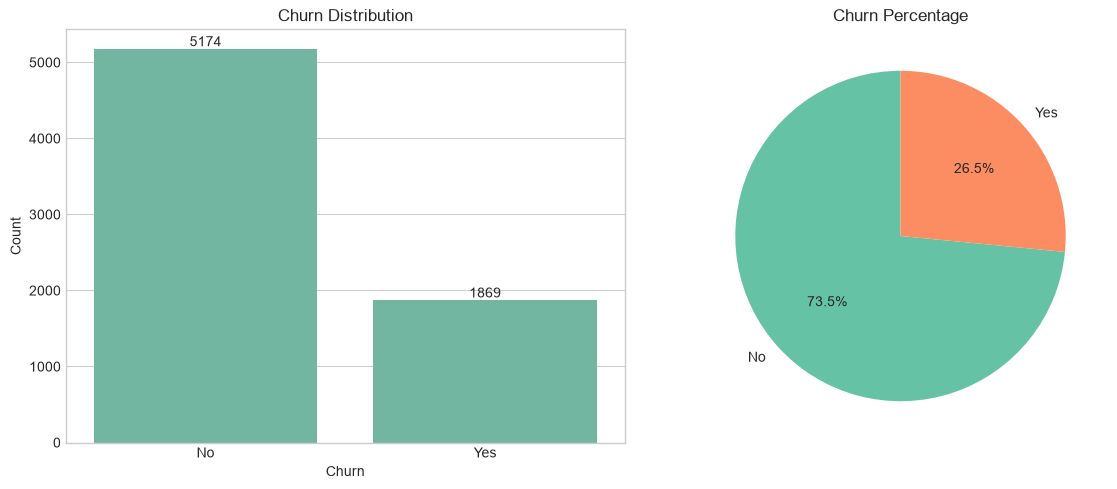

In [7]:
# Check churn distribution
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(churn_counts)
print(f"\nChurn Rate: {churn_percent['Yes']:.2f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(data=df, x='Churn', ax=axes[0])
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Churn')
axes[0].bar_label(axes[0].containers[0])

# Pie chart
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Churn Percentage')

plt.tight_layout()
plt.savefig('../reports/figures/churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Analyse Numerical Features
How numerical features relate to churn

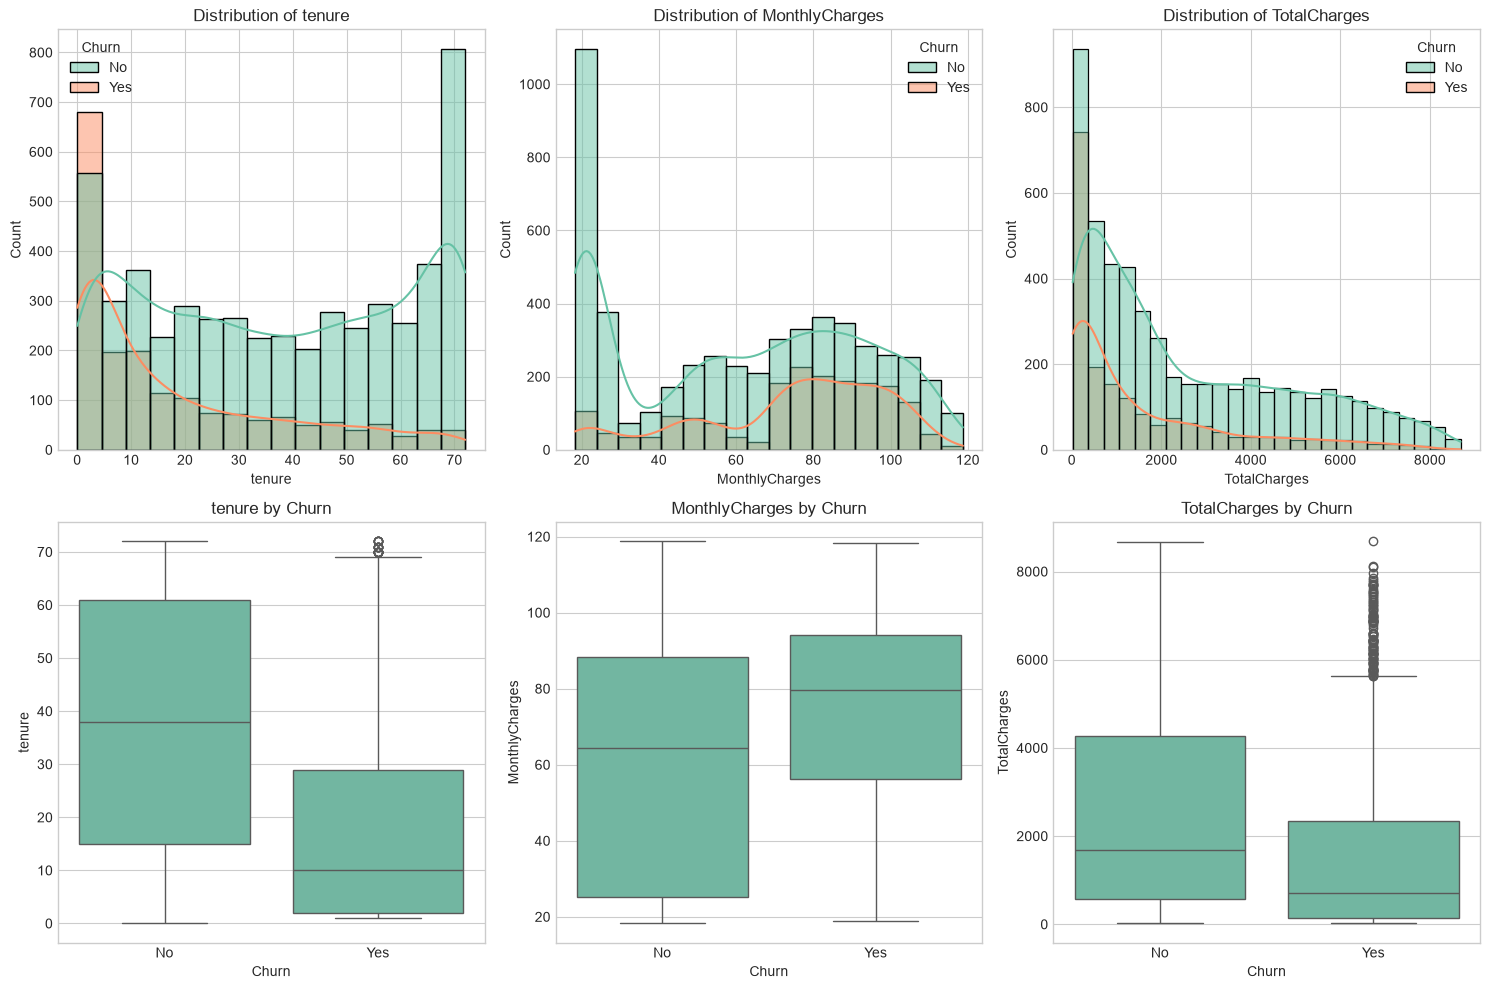

In [8]:
# Numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']


# Create a function to plot distributions
def plot_numerical_features(df, num_cols):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    for i, col in enumerate(num_cols):
        # Distribution histogram
        row, col_idx = i // 3, i % 3
        sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=axes[row, col_idx])
        axes[row, col_idx].set_title(f'Distribution of {col}')
        
        # Box plot for churn comparison
        row2, col_idx2 = (i + 3) // 3, (i + 3) % 3
        sns.boxplot(data=df, x='Churn', y=col, ax=axes[row2, col_idx2])
        axes[row2, col_idx2].set_title(f'{col} by Churn')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/numerical_features.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_numerical_features(df, num_cols)

What is the average tenure(/MonthlyCharges/TotalCharges) for a customer who churns vs. one who stays?

In [9]:
# Statistical comparison of numerical features by churn
df.groupby('Churn')[num_cols].agg(['mean', 'median', 'std'])

tenure                   MonthlyCharges                     \
            mean median        std           mean  median        std   
Churn                                                                  
No     37.569965   38.0  24.113777      61.265124  64.425  31.092648   
Yes    17.979133   10.0  19.531123      74.441332  79.650  24.666053   

      TotalCharges                         
              mean    median          std  
Churn                                      
No     2552.882494  1679.525  2327.590132  
Yes    1531.796094   703.550  1890.822994

Analyze Categorical Features

/var/folders/vs/w1r57qh5159fwwx8w9x2vb380000gn/T/ipykernel_49425/1615888380.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Total categorical columns: 16


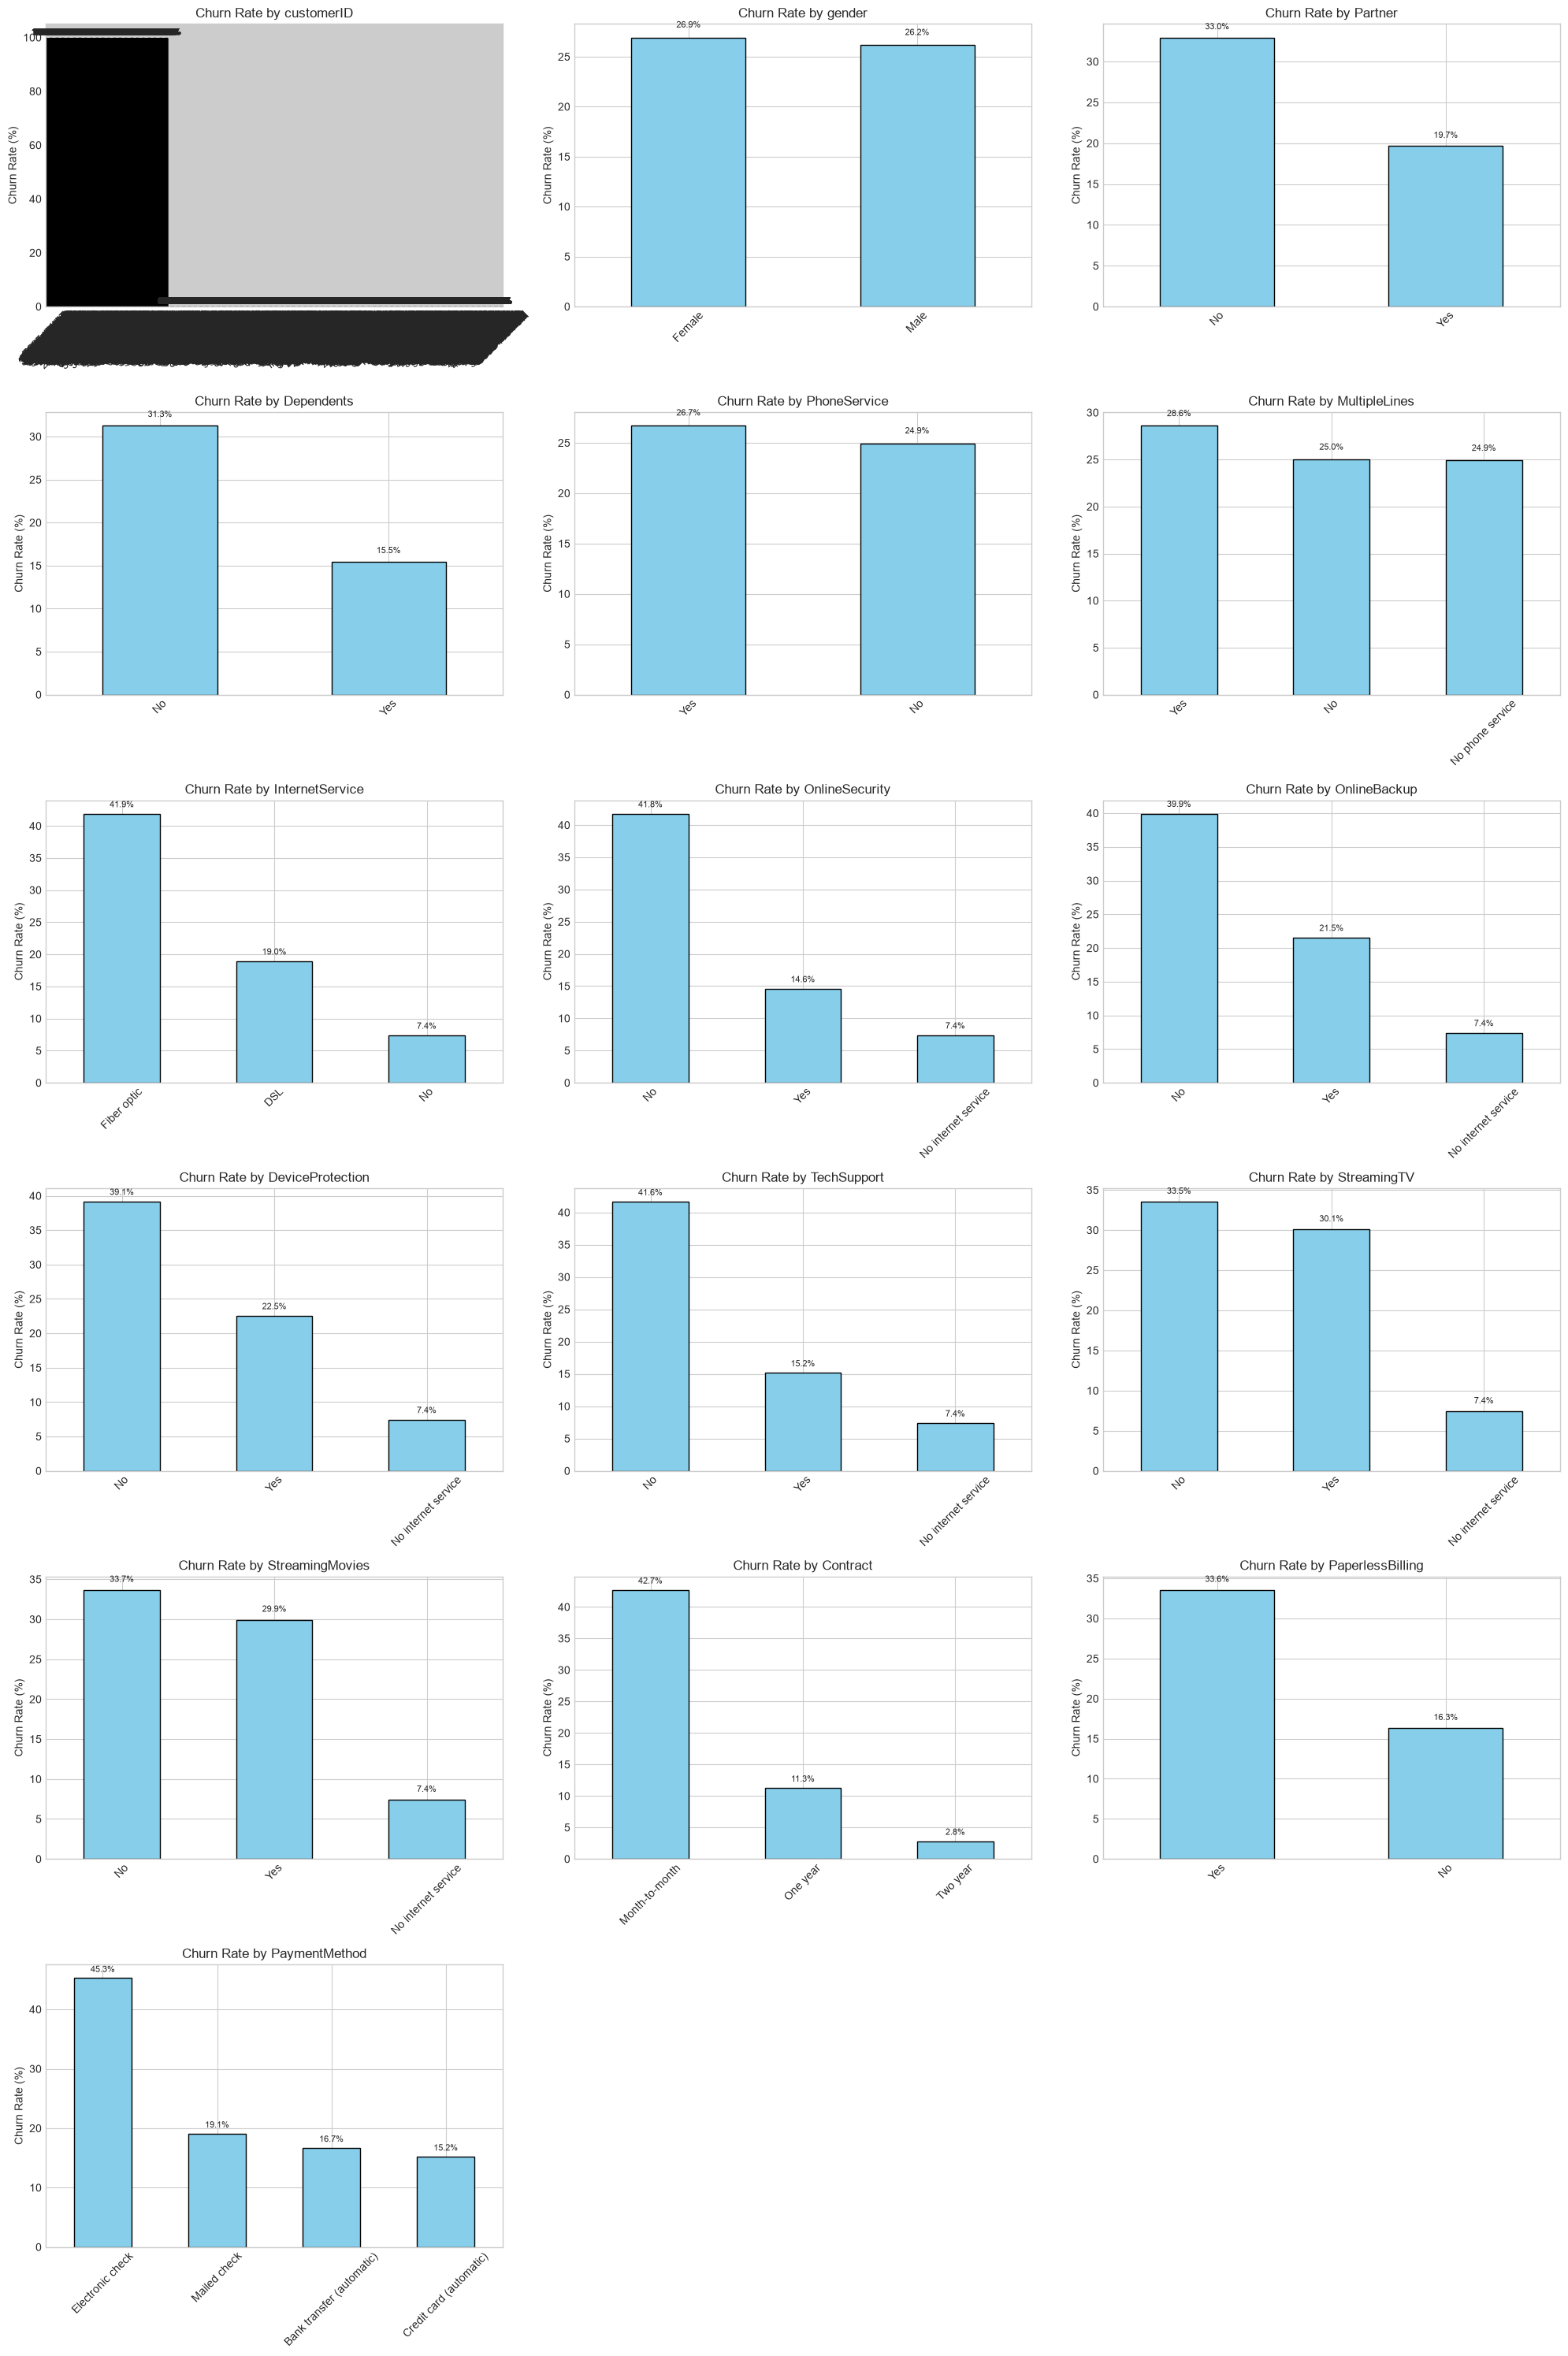

In [10]:
# Identify categorical columns (excluding the target)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('Churn')  # Remove target

print(f"Categorical columns: {cat_cols}")
print(f"Total categorical columns: {len(cat_cols)}")

# Calculate number of rows needed for subplots (3 columns per row)
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols  # Ceiling division

# Create subplots with dynamic sizing
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes]  # Handle single row case

# Plot churn rate by each categorical feature
for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for j, v in enumerate(churn_rate):
        axes[i].text(j, v + 1, f'{v:.1f}%', ha='center', fontsize=8)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('../reports/figures/categorical_churn_rates.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Key insight: Contract type vs churn
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print("Churn Rate by Contract Type:")
print(contract_churn)

Churn Rate by Contract Type:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


## 📌 Key Observations

### 1. Data Overview
- The dataset has 7,043 rows and 21 columns.
- The target variable 'Churn' is imbalanced with ~26.5% churn rate.
- No immediate missing values are visible in most columns.

### 2. Data Quality Issues
- `TotalCharges` is stored as a string/object, needs conversion to numeric.
- Some columns like `SeniorCitizen` are stored as integers (0/1) but should be categorical.

### 3. Customer Demographics
- **Contract Type:** Month-to-month contracts have the highest churn rate (~42%), while those with 1-year contracts churn at ~12% and 2-year contracts at ~2.8%.
- **No Online Security:** Customers without online security churn at ~41% vs ~17% with it.
- **Payment Method:** Electronic check users churn the most (~45%), while those using bank transfer or credit card churn less (~16-17%).

### 4. Numerical Relationships
- **Tenure:** The longer a customer stays, the less likely they are to churn. Newer customers (0-12 months) are at highest risk.
- **Monthly Charges:** Customers with higher monthly charges (e.g., $80+) tend to churn more.
- **Total Charges:** Lower total charges (meaning newer customers) correlate with higher churn.

### 5. Initial Hypothesis
- Customers on short-term contracts with high monthly charges and no additional services (like online security) are prime churn candidates.
- The company should focus retention efforts on month-to-month customers in their first year.

Create a "Tenure Group" feature. 
Tenure (how long a customer has been with the company) is one of the strongest predictors of churn. 

In [14]:
# categorizing tenure into groups for better analysis
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels=['0-1yr', '1-2yrs', '2-4yrs', '4-6yrs'])

#check the distribution of tenure groups
tenure_group_counts = df['tenure_group'].value_counts().sort_index()
print("\nTenure Group Distribution:")
print(tenure_group_counts)


Tenure Group Distribution:
tenure_group
0-1yr     2175
1-2yrs    1024
2-4yrs    1594
4-6yrs    2239
Name: count, dtype: int64


Convert categorical features (like gender, partner, phoneservice) from text to numbers.

In [16]:
# One-hot encode ALL categorical columns at once
# Exclude the target variable 'Churn' because we don't want to encode that
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 
                    'MultipleLines', 'InternetService', 'OnlineSecurity', 
                    'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                    'StreamingTV', 'StreamingMovies', 'Contract', 
                    'PaperlessBilling', 'PaymentMethod']

#convert categorical features to numerical using one-hot encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Check the new shape
print(f"Original shape: {df.shape}")
print(f"Encoded shape: {df_encoded.shape}")

Original shape: (7043, 22)
Encoded shape: (7043, 33)


In [15]:
# Key insight: Payment method vs churn
payment_churn = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print("\nChurn Rate by Payment Method:")
print(payment_churn)



Churn Rate by Payment Method:
PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn, dtype: float64


Save your processed Data

In [17]:
# Save cleaned data
df.to_csv('../data/processed/telco_churn_cleaned.csv', index=False)
print("Cleaned data saved to data/processed/telco_churn_cleaned.csv")

Cleaned data saved to data/processed/telco_churn_cleaned.csv
